In [1]:
import sys
sys.path.append('../')
# from experiments import utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypolo2

# Average pm2.5 concentration for different team size

In [8]:
#区域平均污染物浓度
Setting = pypolo2.utilities.Config()
strategy_name = ["EffectOrientedSelectiveSpray",
                 "Traffic_jam",
                 "NoSpray"]
comparing_variables = [["teamsize_1","teamsize_2","teamsize_3","teamsize_4","teamsize_5"]]
seeds = [7,11,18,20,25,36,42,50,60,72]
team_sizes = [1,2,3,4,5]
sourcenums = [1,2,3,4,5]
change_intervals = [4,8,12]
total_step = 48
sche_step = 0
adaptive_step = 0
strategy_pm25concentration = []
for strategy in strategy_name:
    if strategy == "EffectOrientedMCTSSpray":
        sche_step = 8
        adaptive_step = 8
    else:
        sche_step = 18
        adaptive_step = 3
    variable_pm25concentration = []
    for i in range(5):
        comparing_variable = comparing_variables[0][i]
        team_size = team_sizes[i]
        sourcenum = 3
        seed_pm25concentration = []
        for seed in seeds:
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            # if strategy == "Traffic_jam" and seed == 11:
            #     print(np.mean(data['truth_env'][0:48]))
            time_pm25concentration = []
            for j in range(total_step):
                if j > 24:
                    pm25concentration = np.mean(data['truth_env'][j])
                    time_pm25concentration.append(pm25concentration)
            seed_pm25concentration.append(np.mean(time_pm25concentration))
        # if strategy == "Traffic_jam":
        #     print(seed_pm25concentration)
        variable_pm25concentration.append(np.mean(seed_pm25concentration))
    # if strategy == "Traffic_jam":
    #     print(variable_pm25concentration)    
    strategy_pm25concentration.append(variable_pm25concentration)
strategy_pm25concentration = np.array(strategy_pm25concentration)
strategy_pm25concentration[-1,:] = np.mean(strategy_pm25concentration[-1,:])
print(strategy_pm25concentration)


[[ 65.5657779   45.17274445  31.94083954  31.4359941   28.64389687]
 [ 68.38493105  53.32369931  35.09623211  32.31779824  30.27842298]
 [111.94675583 111.94675583 111.94675583 111.94675583 111.94675583]]


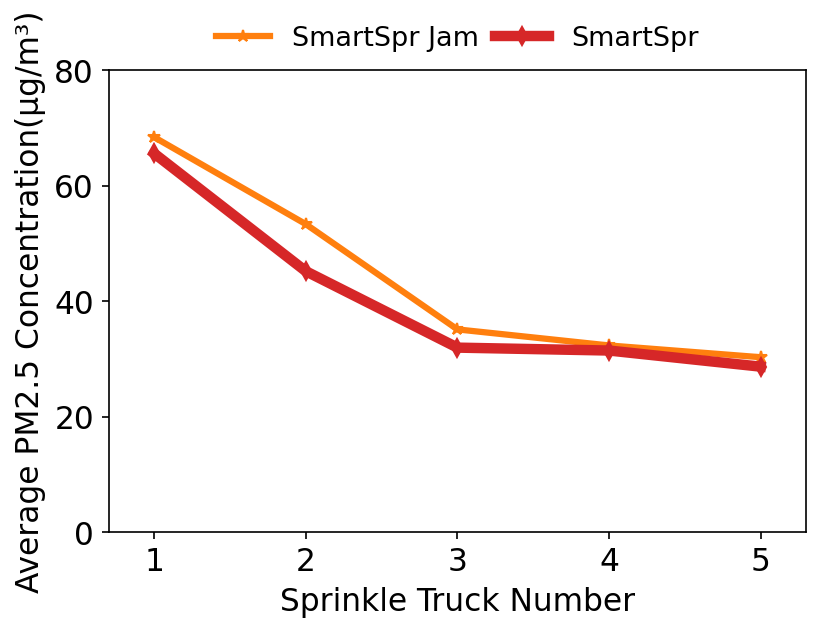

In [9]:
Time_deadline = 5
xtitle = 'Sprinkle Truck Number'
ytitle = 'Average PM2.5 Concentration(μg/m³)'
filename = './outputs/png/line_AverageConcentration-teamszize12345-Trafficjam.png'
colors_dict = ['#d62728', '#ff7f0e', '#1f77b4']
ncol = 3
x_values = range(1, Time_deadline + 1)

plt.rcParams['legend.fontsize'] = 13  # 图例字体大小
plt.rcParams['axes.labelsize'] = 15  # 坐标轴标签字体大小
plt.rcParams['xtick.labelsize'] = 15  # x轴刻度字体大小
plt.rcParams['ytick.labelsize'] = 15  # y轴刻度字体大小

plt.figure(figsize =(6,4),dpi=150)

# plt.plot(x_values, strategy_pm25concentration[2][0:Time_deadline], marker='^', color=colors_dict[2], linewidth=3, label='SmartSpr')
plt.plot(x_values, strategy_pm25concentration[1][0:Time_deadline], marker='*', color=colors_dict[1], linewidth=3, label='SmartSpr Jam')
plt.plot(x_values, strategy_pm25concentration[0][0:Time_deadline], marker='d', color=colors_dict[0], linewidth=5, label='SmartSpr')

plt.xlabel(xtitle)
plt.ylabel(ytitle)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=ncol, frameon=False,columnspacing=0.6)

plt.xlim([1-0.3, Time_deadline+0.3])
plt.ylim([0, 80])

plt.savefig(filename,bbox_inches = 'tight')

# Average pm2.5 concentration for different source number

In [ ]:
# 区域pm2.5平均浓度变化
Setting = pypolo2.utilities.Config()
strategy_name = ["EffectOrientedSelectiveSpray",
                 "Traffic_jam",
                 "NoSpray"]
comparing_variables = [["teamsize_1","teamsize_2","teamsize_3","teamsize_4","teamsize_5"],
                       ["numsource_1","numsource_2","numsource_3","numsource_4","numsource_5"]]
seeds = [7,11,18,20,25,36,42,50,60,72]
team_sizes = [1,2,3,4,5]
sourcenums = [1,2,3,4,5]
strategy_meanpm = []
total_step = 48
sche_step = 0
adaptive_step = 0
strategy_pm25concentration = []
for strategy in strategy_name:
    if strategy == "EffectOrientedMCTSSpray":
        sche_step = 8
        adaptive_step = 8
    else:
        sche_step = 18
        adaptive_step = 3
    variable_pm25concentration = []
    for i in range(5):
        comparing_variable = comparing_variables[1][i]
        team_size = 3
        sourcenum = sourcenums[i]
        seed_pm25concentration = []
        for seed in seeds:
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            time_pm25concentration = []
            for j in range(total_step):
                if j > 24:
                    pm25concentration = np.mean(data['truth_env'][j])
                    time_pm25concentration.append(pm25concentration)
            seed_pm25concentration.append(np.mean(time_pm25concentration))
        variable_pm25concentration.append(np.mean(seed_pm25concentration))
    strategy_pm25concentration.append(variable_pm25concentration)
strategy_pm25concentration = np.array(strategy_pm25concentration)
strategy_pm25concentration[-1,:] = np.mean(strategy_pm25concentration[-1,:])
print(strategy_pm25concentration)


[[ 17.2627893   28.72452682  35.04268389  40.27381385  43.24975462]
 [ 14.52127432  29.28797575  34.89266594  46.15010459  46.96389455]
 [112.04077911 112.04077911 112.04077911 112.04077911 112.04077911]]


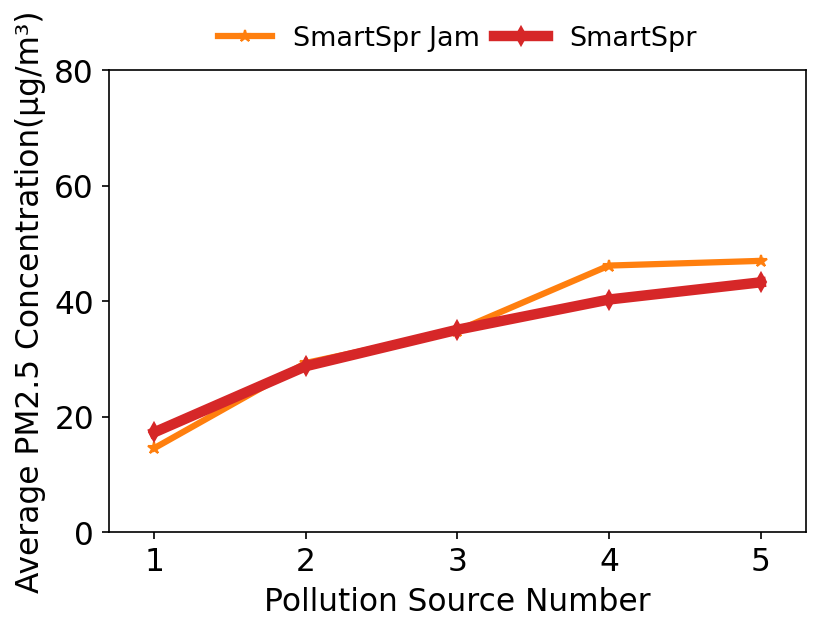

In [6]:
Time_deadline = 5
xtitle = 'Pollution Source Number'
ytitle = 'Average PM2.5 Concentration(μg/m³)'
filename = './outputs/png/line_AverageConcentration-source12345-Trafficjam.png'
colors_dict = ['#d62728', '#ff7f0e', '#1f77b4']
ncol = 3
x_values = range(1, Time_deadline + 1)

plt.rcParams['legend.fontsize'] = 13  # 图例字体大小
plt.rcParams['axes.labelsize'] = 15  # 坐标轴标签字体大小
plt.rcParams['xtick.labelsize'] = 15  # x轴刻度字体大小
plt.rcParams['ytick.labelsize'] = 15  # y轴刻度字体大小

plt.figure(figsize =(6,4),dpi=150)

# plt.plot(x_values, strategy_pm25concentration[2][0:Time_deadline], marker='^', color=colors_dict[2], linewidth=3, label='MaximumCoverage')
plt.plot(x_values, strategy_pm25concentration[1][0:Time_deadline], marker='*', color=colors_dict[1], linewidth=3, label='SmartSpr Jam')
plt.plot(x_values, strategy_pm25concentration[0][0:Time_deadline], marker='d', color=colors_dict[0], linewidth=5, label='SmartSpr')

plt.xlabel(xtitle)
plt.ylabel(ytitle)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=ncol, frameon=False, columnspacing=0.5)

plt.xlim([1-0.3, Time_deadline+0.3])
plt.ylim([0, 80])

plt.savefig(filename,bbox_inches = 'tight')